In [98]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GroupShuffleSplit, GridSearchCV, StratifiedGroupKFold, cross_val_score
from xgboost import XGBClassifier, plot_importance
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
import optuna
import shap

In [99]:
data = pd.read_csv('TD_complete_updated_20241219(in) (1).csv', delimiter=';')


In [100]:
# anonymizing column names
import pandas as pd

# Rename columns to Feature1, Feature2, etc.
data.columns = [f'Feature{i+1}' for i in range(len(data.columns))]

#show the new column names
print(data.columns)

Index(['Feature1', 'Feature2', 'Feature3', 'Feature4', 'Feature5', 'Feature6',
       'Feature7', 'Feature8', 'Feature9', 'Feature10', 'Feature11',
       'Feature12', 'Feature13', 'Feature14', 'Feature15', 'Feature16',
       'Feature17', 'Feature18', 'Feature19', 'Feature20', 'Feature21'],
      dtype='object')


In [36]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2763 entries, 0 to 2781
Data columns (total 21 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Feature1   2763 non-null   int64 
 1   Feature2   2763 non-null   int64 
 2   Feature3   2763 non-null   object
 3   Feature4   2763 non-null   object
 4   Feature5   2763 non-null   object
 5   Feature6   2763 non-null   int64 
 6   Feature7   2763 non-null   int64 
 7   Feature8   2763 non-null   object
 8   Feature9   2763 non-null   object
 9   Feature10  2763 non-null   object
 10  Feature11  2763 non-null   object
 11  Feature12  2763 non-null   object
 12  Feature13  2763 non-null   object
 13  Feature14  2763 non-null   object
 14  Feature15  2763 non-null   object
 15  Feature16  2763 non-null   object
 16  Feature17  2763 non-null   object
 17  Feature18  2763 non-null   object
 18  Feature19  2763 non-null   object
 19  Feature20  2763 non-null   object
 20  Feature21  2763 non-null   int64 
d

In [101]:
#data

In [102]:
target_column = 'Feature21' 

In [ ]:
data['Feature15'] = pd.to_numeric(data['Feature15'], errors='coerce')
data['Feature15'] = data['Feature15'].fillna(data['Feature15'].median())

In [66]:
# find out columns of object dtypes
object_cols = data.select_dtypes(include=["object"]).columns

# get distinct values
for col in object_cols:
    print(f"Distinct values in '{col}' column:")
    print(data[col].unique())
    print("-" * 30)

Distinct values in 'Feature3' column:
['Papier-Masse' 'Mischkabel' 'XLPE']
------------------------------
Distinct values in 'Feature4' column:
['29.04.2021' '27.04.2021' '28.04.2021' '20.04.2023' '10.10.2019'
 '11.10.2019' '13.09.2022' '28.09.2021' '21.10.2021' '14.10.2021'
 '05.10.2021' '04.10.2021' '01.11.2021' '23.09.2021' '06.10.2021'
 '30.09.2021' '22.11.2021' '13.09.2021' '20.09.2021' '08.12.2021'
 '07.10.2021' '12.10.2021' '19.10.2021' '18.10.2021' '20.10.2021'
 '13.10.2021' '11.10.2021' '21.09.2021' '08.09.2021' '16.09.2021'
 '10.06.2021' '14.09.2021' '25.11.2021' '07.09.2021' '09.09.2021'
 '07.12.2021' '10.09.2022' '12.09.2022' '27.09.2021' '06.09.2021'
 '14.11.2022' '17.11.2022' '18.04.2023' '19.04.2023' '15.11.2022'
 '14.12.2022' '16.11.2022' '12.12.2022' '13.12.2022' '15.12.2022'
 '17.04.2023' '18.11.2022']
------------------------------
Distinct values in 'Feature5' column:
['09:42:37' '10:04:43' '15:23:37' '15:18:34' '13:58:51' '14:05:00'
 '11:39:48' '09:09:39' '15:58:17

In [67]:
data.isnull().sum()

Feature1      0
Feature2      0
Feature3      0
Feature4      0
Feature5     18
Feature6      0
Feature7      0
Feature8      0
Feature9      0
Feature10     0
Feature11     0
Feature12     0
Feature13     1
Feature14     1
Feature15     0
Feature16     0
Feature17     0
Feature18     0
Feature19     0
Feature20     0
Feature21     0
dtype: int64

In [68]:
enc = LabelEncoder()
for col in object_cols:
    data[col] = enc.fit_transform(data[col])

In [69]:
for col in object_cols:
    print(f"Distinct values in '{col}' column:")
    print(data[col].unique())
    print("-" * 30)

Distinct values in 'Feature3' column:
[1 0 2]
------------------------------
Distinct values in 'Feature4' column:
[50 46 48 38 13 14 20 49 42 24  2  1  0 44  4 51 43 19 39  9  6 17 37 34
 40 21 15 41  8 29 11 23 45  5 10  7 12 16 47  3 25 32 33 36 27 26 30 18
 22 28 31 35]
------------------------------
Distinct values in 'Feature5' column:
[ 32  44 139 138 125 127  79  19 144 114  77 117  29 137  73 128  94  57
 143  17  58 101 136  25  90  54 145 135  13  26 104  35  24  65  27  87
 113  81  43  22  49  86 119  16  23 121  71  40  33  89  98  46  72 118
  48 103 115  67  75  70  30  93 120 142  61   4 110  18 126  91  97  38
 111 140  62  28  63  76  20  59 106  60  92 124  15 108  51 102  56  21
   9   3  52   0  10  11  50   6  36 123   1  47  39   8  37 131   7  42
  85 134 112  96  82 107  45  64 129  69 100  12  83 105 122  78  84 130
  99 133 116  31 132  55  88  66  68  74 141  14  34 146  80  53   5  41
   2  95 109]
------------------------------
Distinct values in 'Feature

           Feature1  Feature2  Feature3  Feature4  Feature5  Feature6  \
Feature1   1.000000  0.722170 -0.248724 -0.030774 -0.055235  0.735285   
Feature2   0.722170  1.000000 -0.398860  0.186089  0.057184  0.964872   
Feature3  -0.248724 -0.398860  1.000000 -0.114434 -0.135012 -0.446214   
Feature4  -0.030774  0.186089 -0.114434  1.000000  0.137035  0.110764   
Feature5  -0.055235  0.057184 -0.135012  0.137035  1.000000  0.058584   
Feature6   0.735285  0.964872 -0.446214  0.110764  0.058584  1.000000   
Feature7   0.001778  0.004016 -0.004112  0.009550  0.001191  0.010597   
Feature8  -0.113364 -0.123283  0.067805 -0.007179  0.010246 -0.122699   
Feature9   0.187193  0.337655 -0.332964 -0.026437 -0.069621  0.363959   
Feature10  0.275036  0.299524 -0.036846 -0.069339 -0.158461  0.313540   
Feature11  0.048991  0.118050 -0.182047 -0.066602 -0.032872  0.149878   
Feature12 -0.038444 -0.047293 -0.077940 -0.045851  0.017913 -0.029037   
Feature13  0.173988  0.338432 -0.314239 -0.035659 -

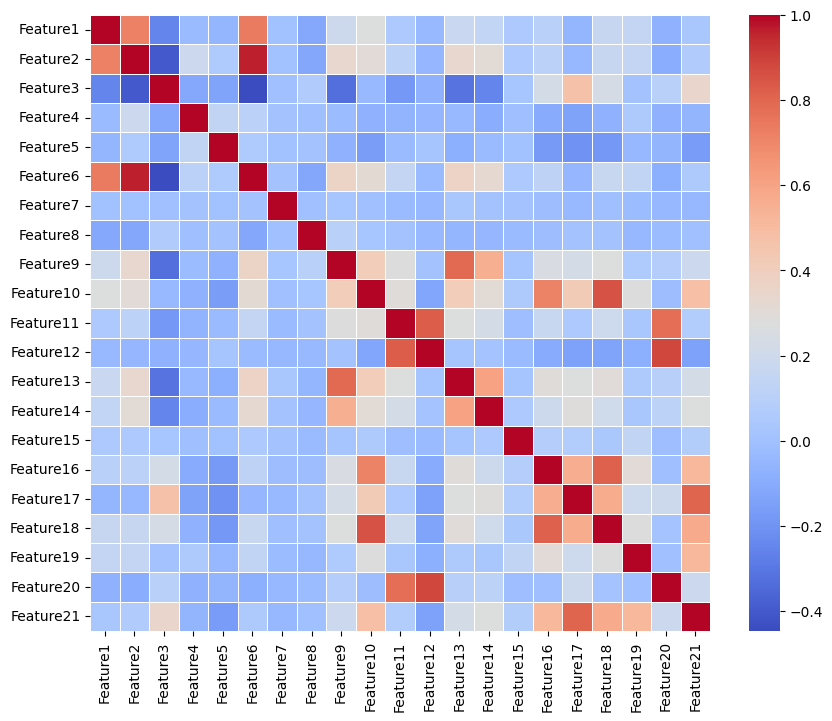

In [70]:
correlation_matrix = data.corr()
print(correlation_matrix)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=False, cmap="coolwarm", linewidths=0.5)
plt.show()

           Feature2  Feature3  Feature7  Feature8  Feature9  Feature10  \
Feature2   1.000000 -0.398860  0.004016 -0.123283  0.337655   0.299524   
Feature3  -0.398860  1.000000 -0.004112  0.067805 -0.332964  -0.036846   
Feature7   0.004016 -0.004112  1.000000 -0.001604  0.025057  -0.000298   
Feature8  -0.123283  0.067805 -0.001604  1.000000  0.097695   0.026875   
Feature9   0.337655 -0.332964  0.025057  0.097695  1.000000   0.411067   
Feature10  0.299524 -0.036846 -0.000298  0.026875  0.411067   1.000000   
Feature11  0.118050 -0.182047 -0.032471  0.011034  0.280351   0.289071   
Feature12 -0.047293 -0.077940 -0.041777 -0.037984  0.011215  -0.128515   
Feature13  0.338432 -0.314239  0.039171 -0.055425  0.792701   0.409434   
Feature14  0.306833 -0.252652  0.008452 -0.046922  0.556166   0.307696   
Feature15  0.049087  0.027227  0.007143 -0.033809  0.018799   0.054337   
Feature20 -0.092467  0.098972 -0.044969 -0.026211  0.080738  -0.017097   
Feature21  0.064252  0.345880 -0.04061

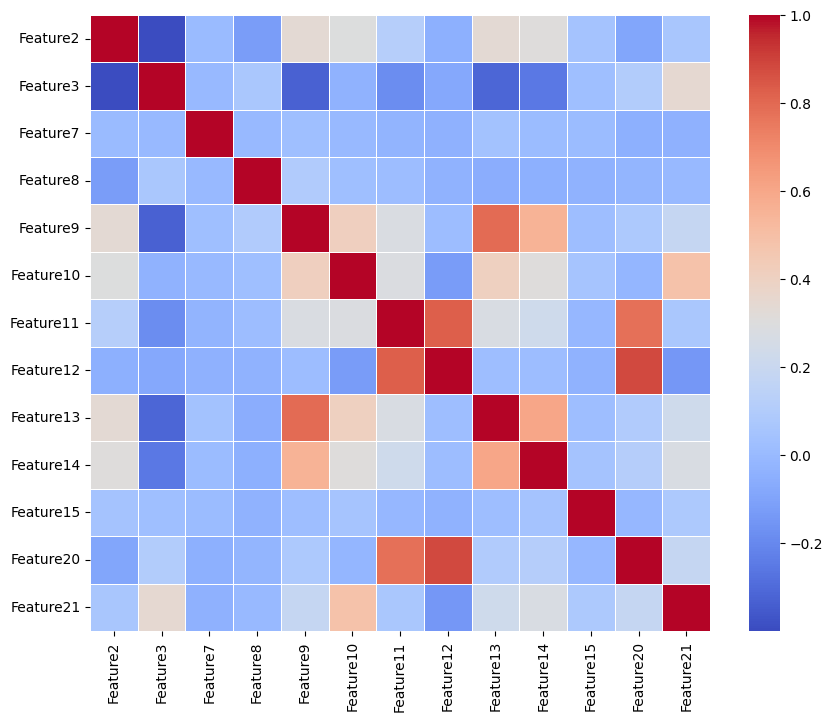

In [ ]:
# drop columns with no relevance except feature2. It is a unique identifier for each row
data_for_analysis = data.drop(['Feature1', 'Feature4', 'Feature5', 'Feature6', 'Feature16', 'Feature17', 'Feature18', 'Feature19'], axis=1)  
correlation_matrix = data_for_analysis.corr()
print(correlation_matrix)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=False, cmap="coolwarm", linewidths=0.5)
plt.show()

In [72]:
#data_for_analysis

In [ ]:
# Drop rows where 'feature9' > 4000 and 'feature10' > 5000 to remove the extreme condition
data_for_analysis = data_for_analysis[~((data_for_analysis['Feature9'] > 4000) & (data_for_analysis['Feature10'] > 5000))] #MTD STD

In [ ]:
# Column to group by but not use for training
group_column = 'Feature2'   
groups = data_for_analysis['Feature2']  

In [75]:
# Get input/output dataframes
y = data_for_analysis[target_column]
x = data_for_analysis.drop([target_column, group_column],axis=1)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_17256\579111297.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[3.95124372 3.66356165 4.4308168  ... 4.70048037 4.87519732 4.97673374]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data_for_analysis.loc[:, numerical_features] = data_for_analysis[numerical_features].apply(safe_log_transform)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_17256\579111297.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[7.6666902  7.38274645 6.27098843 ... 2.30258509 2.77258872 2.56494936]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data_for_analysis.loc[:, numerical_features] = data_for_analysis[numerical_features].apply(safe_log_transform)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_17256\579111297.py:10: FutureWarning:

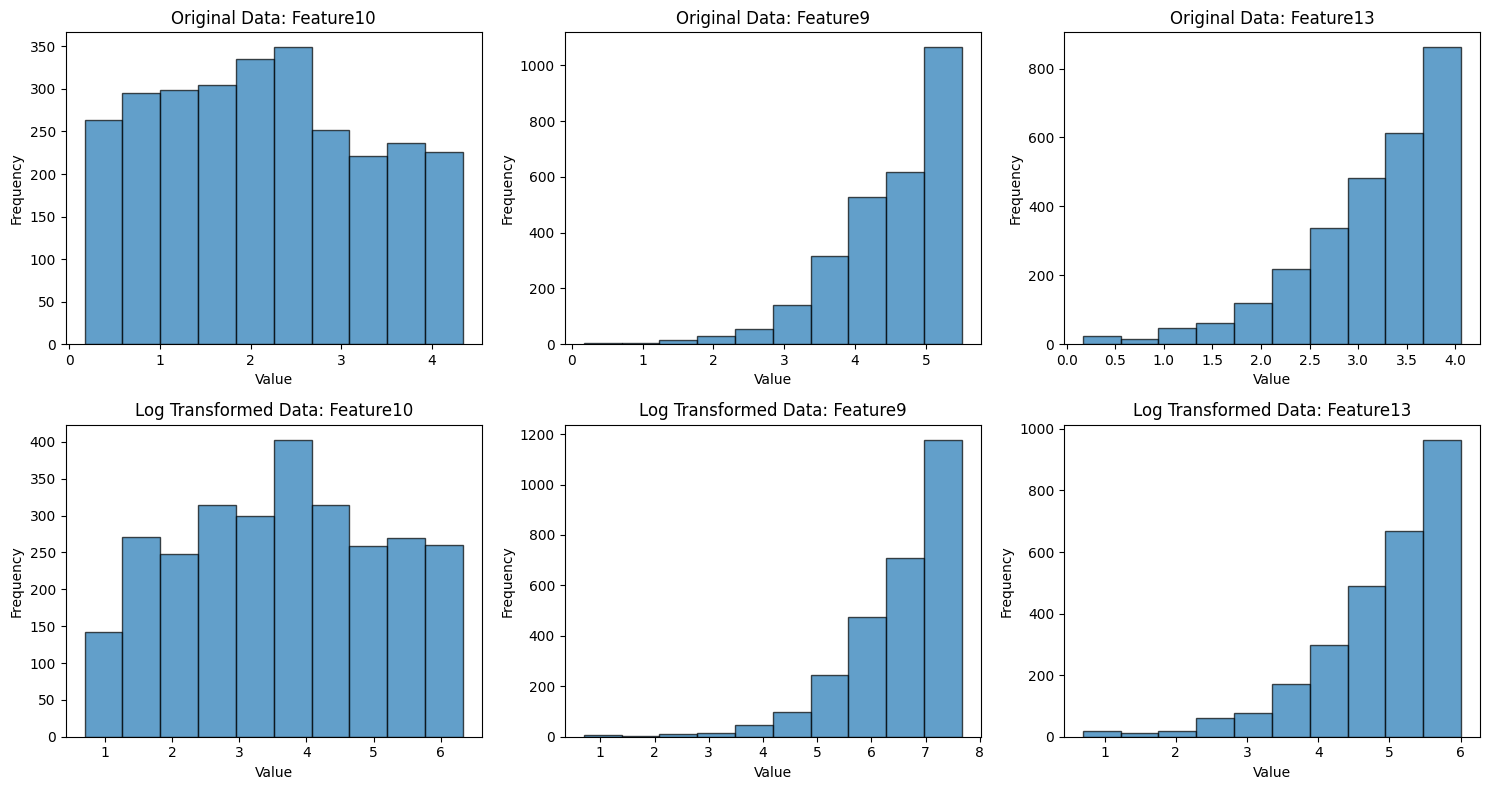

In [ ]:
# Define numerical features
numerical_features = ['Feature10', 'Feature9', 'Feature13'] 

# Define the safe log transform function
def safe_log_transform(series):
    min_value = series.min()
    return np.log1p(series - min_value + 1) if min_value <= 0 else np.log1p(series)

# Apply log transformation with safe_log_transform
data_for_analysis.loc[:, numerical_features] = data_for_analysis[numerical_features].apply(safe_log_transform)

# Plot original vs. transformed data
fig, axes = plt.subplots(2, len(numerical_features), figsize=(15, 8))
titles = ["Original Data", "Log Transformed Data"]

for i, col in enumerate(numerical_features):
    for j, (data, title) in enumerate(zip(
        [data_for_analysis[col] - np.log1p(data_for_analysis[col]), data_for_analysis[col]], titles
    )):
        axes[j, i].hist(data, bins=10, edgecolor='k', alpha=0.7)
        axes[j, i].set_title(f"{title}: {col}")
        axes[j, i].set_xlabel("Value")
        axes[j, i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [77]:
# Standard deviation before scaling
x.std()

Feature3       0.807080
Feature7       0.816699
Feature8       2.974251
Feature9     624.093111
Feature10    132.026334
Feature11    528.339298
Feature12      0.953905
Feature13    115.445135
Feature14    115.474037
Feature15      8.273427
Feature20      2.398766
dtype: float64

In [78]:
# apply scaling
scaler = StandardScaler()
scaled_features = scaler.fit_transform(x)
x_standardized = pd.DataFrame(scaled_features, columns=x.columns)

In [79]:
# standard deviation after scaling
x_standardized.std()

Feature3     1.00018
Feature7     1.00018
Feature8     1.00018
Feature9     1.00018
Feature10    1.00018
Feature11    1.00018
Feature12    1.00018
Feature13    1.00018
Feature14    1.00018
Feature15    1.00018
Feature20    1.00018
dtype: float64

In [80]:
x_standardized.columns

Index(['Feature3', 'Feature7', 'Feature8', 'Feature9', 'Feature10',
       'Feature11', 'Feature12', 'Feature13', 'Feature14', 'Feature15',
       'Feature20'],
      dtype='object')

In [81]:
# Initialize GroupShuffleSplit
gss = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

# Split the data
train_idx, test_idx = next(gss.split(x_standardized, y, groups=groups))

# Create train and test sets
X_train, X_test = x_standardized.iloc[train_idx], x_standardized.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]


### Supervised Modelling

#### XGBoost

In [82]:
def xgboost_classifier(X, y, objective='multi:softmax', learning_rate=0.1, n_estimators=100):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20, stratify=y)
    
    # Create XGBClassifier with given parameters
    model = XGBClassifier(
        objective=objective,
        learning_rate=learning_rate,
        max_depth=4,
        n_estimators=n_estimators,
        random_state=20
    )
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions on the test set
    y_pred = model.predict(X_test)
    
    ## Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")
    
    # Plot confusion matrix
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=np.unique(y_test) + 1, 
            yticklabels=np.unique(y_test) + 1)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()
    
    return model, accuracy, f1, cm


Accuracy: 0.8869
F1 Score: 0.8773


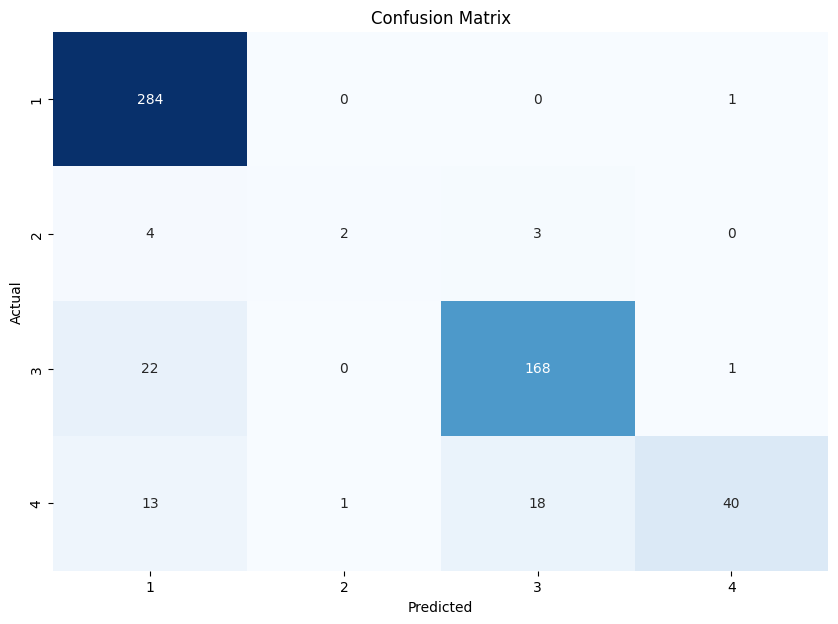

<Figure size 1000x600 with 0 Axes>

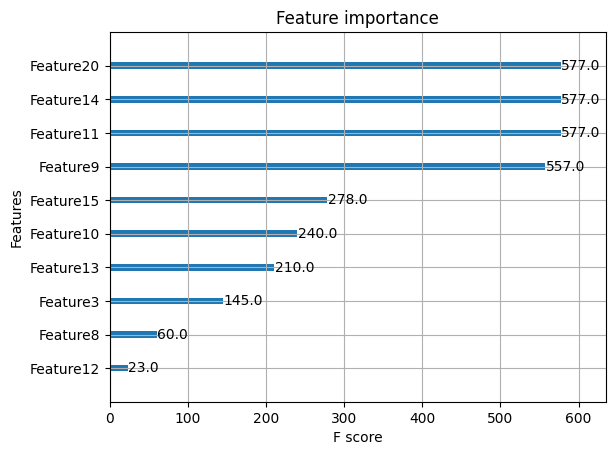

In [46]:
y_adjusted = y.values.ravel() - 1

model, acc, f1, cm = xgboost_classifier(x_standardized, y_adjusted, objective='multi:softmax', learning_rate=0.001, n_estimators=100)

# Plot feature importance
plt.figure(figsize=(10, 6))
plot_importance(model)
plt.show()


In [83]:

def objective_xgb(trial, X_train, y_train, cv=3):
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.2, step=0.01)
    max_depth = trial.suggest_int('max_depth', 3, 6, step=1)
    n_estimators = trial.suggest_int('n_estimators', 50, 200, step=10)
    subsample = trial.suggest_float('subsample', 0.8, 1.0, step=0.1)
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0, step=0.1)
    gamma = trial.suggest_float('gamma', 0, 5, step=1)

    # Initialize model
    xgb = XGBClassifier(
        objective='multi:softmax',
        learning_rate=learning_rate,
        max_depth=max_depth,
        n_estimators=n_estimators,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        gamma=gamma,
        random_state=20,
        eval_metric='mlogloss',
        n_jobs=-1
    )

    # Cross-validation score (weighted F1-score)
    f1 = cross_val_score(xgb, X_train, y_train, cv=cv, scoring='f1_weighted', n_jobs=-1).mean()
    
    return f1

In [84]:
def xgboost_classifier_with_optuna(X, y, n_trials=30, cv=3):
    """Runs Optuna to optimize hyperparameters and train the best XGBoost model."""
    
    # Split dataset
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20, stratify=y)
    
    # Create Optuna study
    study = optuna.create_study(direction='maximize')
    study.optimize(lambda trial: objective_xgb(trial, X_train, y_train, cv=cv), n_trials=n_trials)
    
    # Get best hyperparameters
    best_params = study.best_params
    print("Best Parameters:", best_params)
    
    # Train final model with best parameters
    best_model = XGBClassifier(**best_params, objective='multi:softmax', random_state=20, eval_metric='mlogloss', n_jobs=-1)
    best_model.fit(X_train, y_train)
    
    # Predictions
    y_pred = best_model.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    cm = confusion_matrix(y_test, y_pred)

    print(f"Test Accuracy: {accuracy:.4f}")
    print(f"Test F1 Score: {f1:.4f}")

    # Plot confusion matrix
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
                xticklabels=np.unique(y_test), 
                yticklabels=np.unique(y_test))
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

    return best_model, best_params, accuracy, f1, cm

[I 2025-05-07 17:51:16,891] A new study created in memory with name: no-name-74f18579-c8df-4d09-991b-d22a0441faa7
[I 2025-05-07 17:51:18,961] Trial 0 finished with value: 0.8968264697709835 and parameters: {'learning_rate': 0.09999999999999999, 'max_depth': 6, 'n_estimators': 80, 'subsample': 0.8, 'colsample_bytree': 0.8, 'gamma': 4.0}. Best is trial 0 with value: 0.8968264697709835.
[I 2025-05-07 17:51:20,598] Trial 1 finished with value: 0.8978349664030367 and parameters: {'learning_rate': 0.14, 'max_depth': 5, 'n_estimators': 160, 'subsample': 1.0, 'colsample_bytree': 0.6, 'gamma': 5.0}. Best is trial 1 with value: 0.8978349664030367.
[I 2025-05-07 17:51:22,078] Trial 2 finished with value: 0.8912374253750089 and parameters: {'learning_rate': 0.04, 'max_depth': 5, 'n_estimators': 130, 'subsample': 0.9, 'colsample_bytree': 1.0, 'gamma': 5.0}. Best is trial 1 with value: 0.8978349664030367.
[I 2025-05-07 17:51:22,281] Trial 3 finished with value: 0.9095958634406975 and parameters: {'l

Best Parameters: {'learning_rate': 0.16, 'max_depth': 5, 'n_estimators': 60, 'subsample': 0.8, 'colsample_bytree': 0.5, 'gamma': 0.0}
Test Accuracy: 0.9264
Test F1 Score: 0.9202


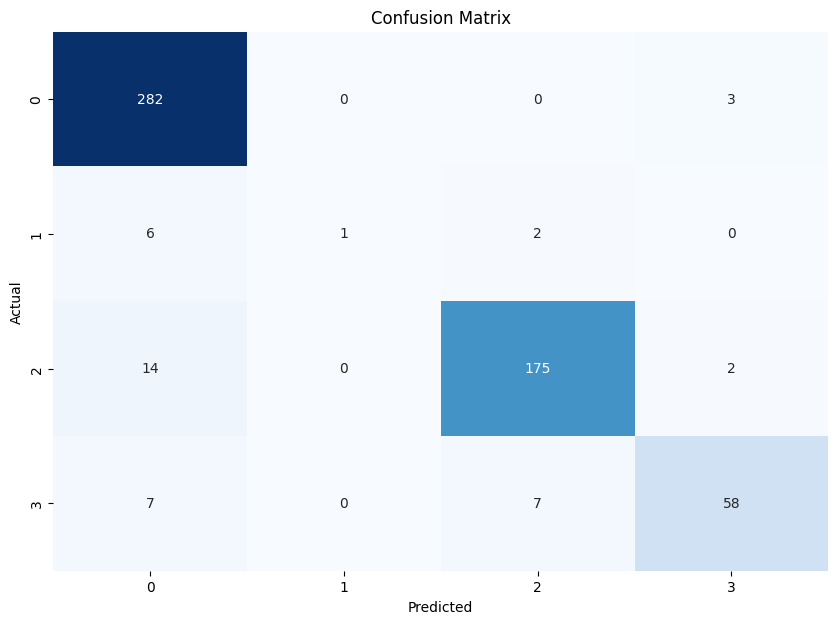

Optimal Parameters: {'learning_rate': 0.16, 'max_depth': 5, 'n_estimators': 60, 'subsample': 0.8, 'colsample_bytree': 0.5, 'gamma': 0.0}
Test Accuracy: 0.926391382405745
F1 Score: 0.920178445133562


In [85]:
best_model_xgb, best_params, accuracy, f1, cm = xgboost_classifier_with_optuna(x_standardized, y_adjusted, n_trials=30, cv=3)

# Results
print(f"Optimal Parameters: {best_params}")
print(f"Test Accuracy: {accuracy}")
print(f"F1 Score: {f1}")


#### Random Forest

In [86]:
def random_forest_classifier(X, y, n_estimators=100, criterion='gini'):
    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20)
    
    # Create RandomForestClassifier with given parameters
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        criterion=criterion,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=1,
        random_state=20
    )
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions on the test set
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")
    
    # Plot confusion matrix
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=np.unique(y_test) + 1, 
            yticklabels=np.unique(y_test) + 1)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()
    
    return model, accuracy, f1, cm


Accuracy: 0.9138
F1 Score: 0.9069


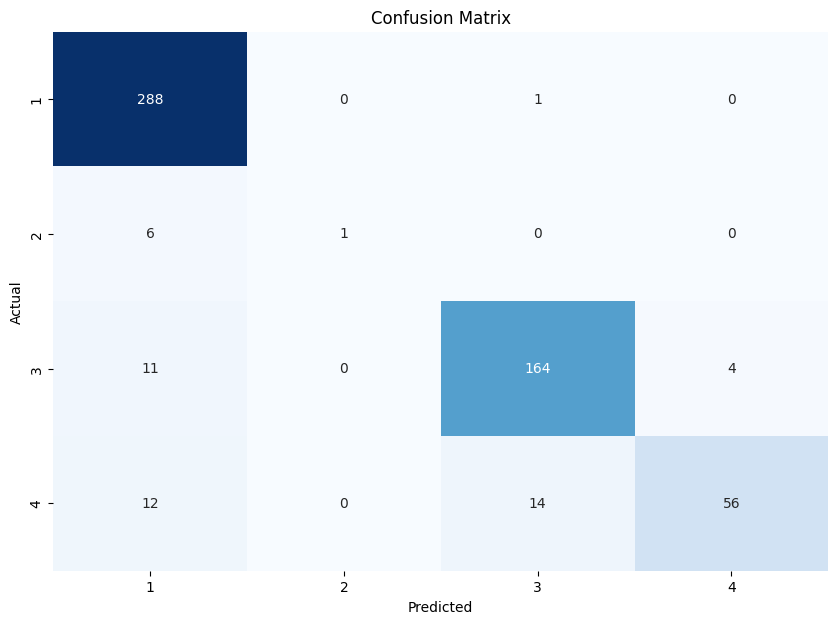

In [87]:
y_adjusted = y.values.ravel() - 1

model, acc, f1, cm = random_forest_classifier(x_standardized, y_adjusted, n_estimators=100, criterion='gini')


      Feature  Importance
10  Feature20    0.321271
8   Feature14    0.153036
0    Feature3    0.140261
4   Feature10    0.128778
7   Feature13    0.083592
5   Feature11    0.065407
3    Feature9    0.054305
6   Feature12    0.027195
2    Feature8    0.013846
1    Feature7    0.007497
9   Feature15    0.004811


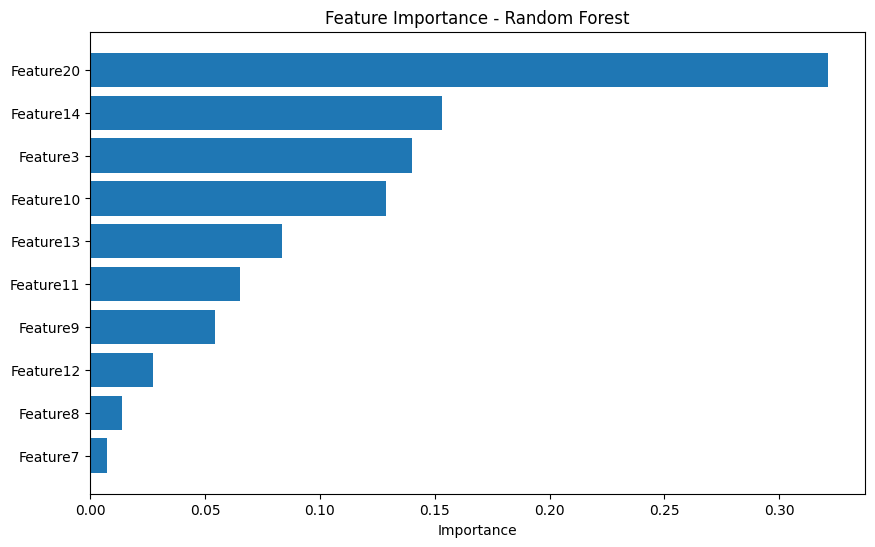

In [88]:
importance_scores = model.feature_importances_
# Create a DataFrame to sort the scores
feature_importance_df = pd.DataFrame({
    'Feature': x_standardized.columns,
    'Importance': importance_scores
})

# Sort the DataFrame by importance
sorted_features = feature_importance_df.sort_values(by='Importance', ascending=False)

# Display sorted feature importance
print(sorted_features)

# Plot top 10 important features
plt.figure(figsize=(10, 6))
plt.barh(sorted_features['Feature'][:10][::-1], sorted_features['Importance'][:10][::-1])
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.show()

In [89]:
def objective_rf(trial, X_train, y_train):
    """Objective function for Optuna to optimize RandomForest hyperparameters."""
    
    # Define search space
    n_estimators = trial.suggest_int('n_estimators', 50, 200, step=10)
    criterion = trial.suggest_categorical('criterion', ['gini', 'entropy'])
    max_depth = trial.suggest_int('max_depth', 5, 20, step=5)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10, step=1)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 4, step=1)

    # Initialize model
    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        criterion=criterion,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=20,
        n_jobs=-1
    )

    # Cross-validation score (weighted F1-score)
    f1 = cross_val_score(rf, X_train, y_train, cv=5, scoring='f1_weighted', n_jobs=-1).mean()
    
    return f1  # Optuna tries to maximize this

In [90]:
def random_forest_classifier_with_optuna(X, y, n_trials=30):
    # Split dataset
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20)
    
    # Create Optuna study
    study = optuna.create_study(direction='maximize')
    study.optimize(lambda trial: objective_rf(trial, X_train, y_train), n_trials=n_trials)
    
    # Get best hyperparameters
    best_params = study.best_params
    print("Best Parameters:", best_params)
    
    # Train final model with best parameters
    best_model = RandomForestClassifier(**best_params, random_state=20, n_jobs=-1)
    best_model.fit(X_train, y_train)
    
    # Predictions
    y_pred = best_model.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    cm = confusion_matrix(y_test, y_pred)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")

    # Plot confusion matrix
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

    return best_model, best_params, accuracy, f1, cm

[I 2025-05-07 17:51:55,358] A new study created in memory with name: no-name-c305f524-629c-4892-8921-a480a2cb36ad
[I 2025-05-07 17:51:55,951] Trial 0 finished with value: 0.9177800186996887 and parameters: {'n_estimators': 110, 'criterion': 'entropy', 'max_depth': 20, 'min_samples_split': 6, 'min_samples_leaf': 1}. Best is trial 0 with value: 0.9177800186996887.
[I 2025-05-07 17:51:56,617] Trial 1 finished with value: 0.9185489741625382 and parameters: {'n_estimators': 180, 'criterion': 'gini', 'max_depth': 20, 'min_samples_split': 2, 'min_samples_leaf': 1}. Best is trial 1 with value: 0.9185489741625382.
[I 2025-05-07 17:51:57,089] Trial 2 finished with value: 0.9030511136924462 and parameters: {'n_estimators': 160, 'criterion': 'gini', 'max_depth': 20, 'min_samples_split': 8, 'min_samples_leaf': 4}. Best is trial 1 with value: 0.9185489741625382.
[I 2025-05-07 17:51:57,764] Trial 3 finished with value: 0.911451671326428 and parameters: {'n_estimators': 190, 'criterion': 'entropy', 'm

Best Parameters: {'n_estimators': 190, 'criterion': 'entropy', 'max_depth': 20, 'min_samples_split': 2, 'min_samples_leaf': 1}
Accuracy: 0.9228
F1 Score: 0.9188


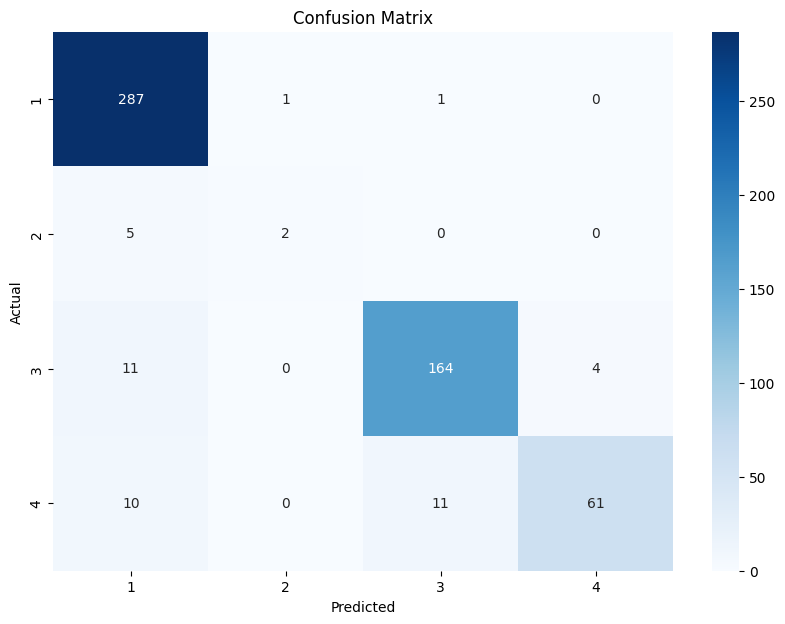

In [91]:
# Perform hyperparameter tuning and retrieve the best parameters
best_rf_model, best_rf_params, accuracy, f1, cm = random_forest_classifier_with_optuna(x_standardized, y)

#### KNN 

In [92]:
def knn_classifier(X, y, n_neighbors=5, metric='minkowski', p=2):
    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20)
    
    # Create KNN classifier with given parameters
    model = KNeighborsClassifier(
        n_neighbors=n_neighbors,
        metric=metric,
        p=p
    )
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions on the test set
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")
    
    # Plot confusion matrix
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()
    
    return model, accuracy, f1, cm


In [93]:
def knn_hyperparameter_tuning(X, y):
    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20)
    
    # Define the parameter grid
    param_grid = {
        'n_neighbors': [3, 5, 7, 9, 11],
        'metric': ['euclidean', 'manhattan', 'minkowski'],
        'p': [1, 2]
    }
    
    # Create a KNN model
    knn = KNeighborsClassifier()
    
    # Perform GridSearchCV
    grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy')
    grid_search.fit(X_train, y_train)
    
    # Best parameters and score
    print("Best Parameters:", grid_search.best_params_)
    print("Best Score:", grid_search.best_score_)
    
    return grid_search.best_estimator_


Accuracy: 0.8779
F1 Score: 0.8702


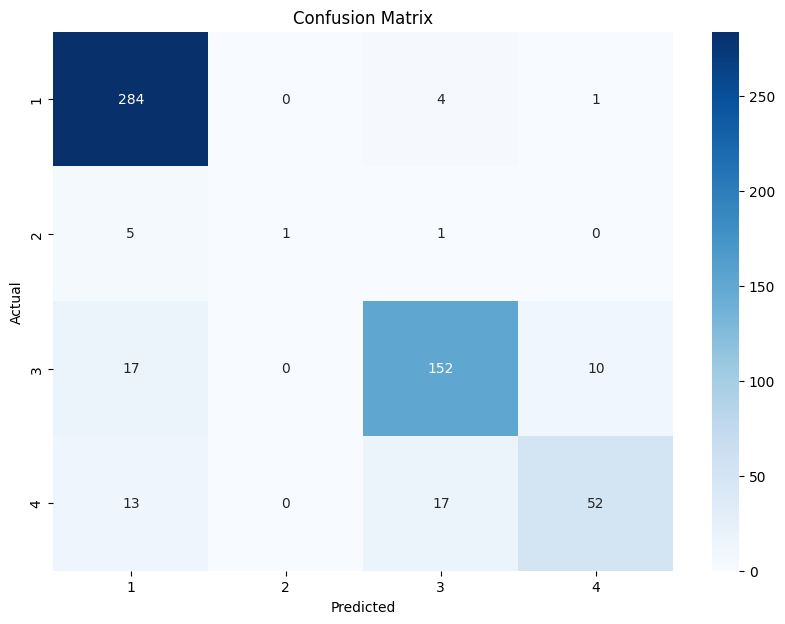

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 3, 'p': 1}
Best Score: 0.8746067415730338


In [94]:
model, acc, f1, cm = knn_classifier(x_standardized, y, n_neighbors=5, metric='minkowski', p=1)
knn_best_params = knn_hyperparameter_tuning(x_standardized, y)

#### Progressive Validation

In [95]:
def progressive_validation(model, X, y, groups):
    splits = [0.2, 0.4, 0.6, 0.8]
    results = []
    
    # Reset index to avoid mismatches
    X, y, groups = X.reset_index(drop=True), y.reset_index(drop=True), groups.reset_index(drop=True)
    sorted_indices = np.argsort(groups.to_numpy()) 
    X, y, groups = X.iloc[sorted_indices], y.iloc[sorted_indices], groups.iloc[sorted_indices]

    gss = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
    train_idx, test_idx = next(gss.split(X, y, groups=groups))

    X_test, y_test = X.iloc[test_idx], y.iloc[test_idx]

    for split in splits:
        subset_idx = train_idx[:int(len(train_idx) * split)]  
        X_train, y_train = X.iloc[subset_idx], y.iloc[subset_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted')
        cm = confusion_matrix(y_test, y_pred)

        results.append({
            'split': f'{int(split * 100)}% train / 20% test',
            'accuracy': accuracy,
            'f1_score': f1,
            'confusion_matrix': cm
        })

        # Plot confusion matrix
        plt.figure(figsize=(6, 4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                    xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
        plt.title(f"Confusion Matrix for {int(split * 100)}% Train / 20% Test")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()

        print(f"Results for {int(split * 100)}% train / 20% test:")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"F1 Score: {f1:.4f}")
        print("-" * 40)
    
    return results

XGBoost Results:


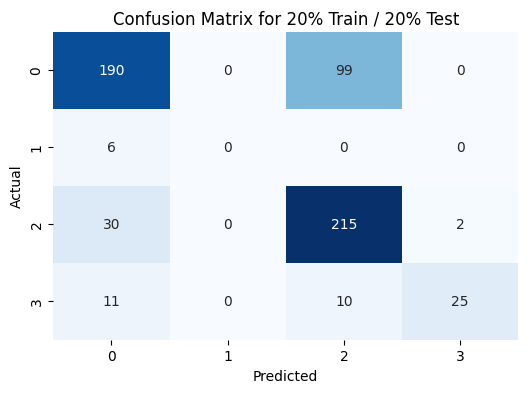

Results for 20% train / 20% test:
Accuracy: 0.7313
F1 Score: 0.7250
----------------------------------------


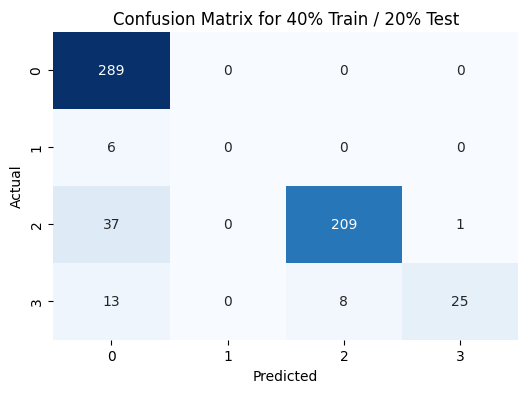

Results for 40% train / 20% test:
Accuracy: 0.8895
F1 Score: 0.8808
----------------------------------------


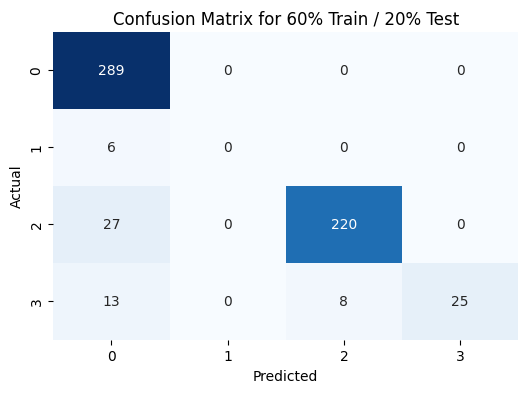

Results for 60% train / 20% test:
Accuracy: 0.9082
F1 Score: 0.8995
----------------------------------------


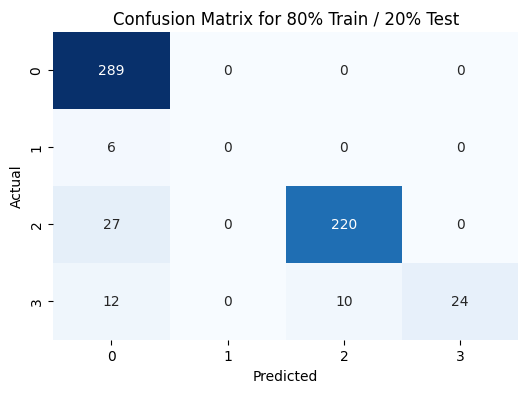

Results for 80% train / 20% test:
Accuracy: 0.9065
F1 Score: 0.8971
----------------------------------------
{'split': '20% train / 20% test', 'accuracy': 0.7312925170068028, 'f1_score': np.float64(0.7249951097465751), 'confusion_matrix': array([[190,   0,  99,   0],
       [  6,   0,   0,   0],
       [ 30,   0, 215,   2],
       [ 11,   0,  10,  25]])}
{'split': '40% train / 20% test', 'accuracy': 0.8894557823129252, 'f1_score': np.float64(0.880834288433335), 'confusion_matrix': array([[289,   0,   0,   0],
       [  6,   0,   0,   0],
       [ 37,   0, 209,   1],
       [ 13,   0,   8,  25]])}
{'split': '60% train / 20% test', 'accuracy': 0.9081632653061225, 'f1_score': np.float64(0.8994725833634284), 'confusion_matrix': array([[289,   0,   0,   0],
       [  6,   0,   0,   0],
       [ 27,   0, 220,   0],
       [ 13,   0,   8,  25]])}
{'split': '80% train / 20% test', 'accuracy': 0.9064625850340136, 'f1_score': np.float64(0.8971236881708341), 'confusion_matrix': array([[289,   0, 

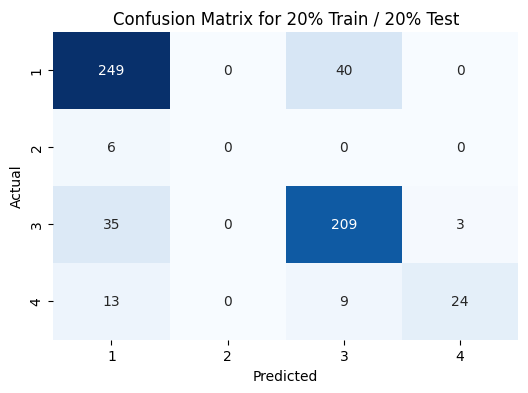

Results for 20% train / 20% test:
Accuracy: 0.8197
F1 Score: 0.8126
----------------------------------------


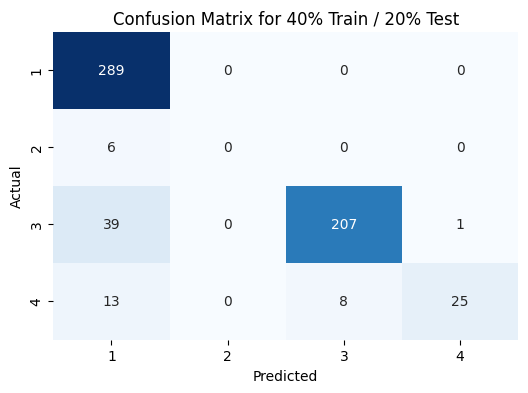

Results for 40% train / 20% test:
Accuracy: 0.8861
F1 Score: 0.8774
----------------------------------------


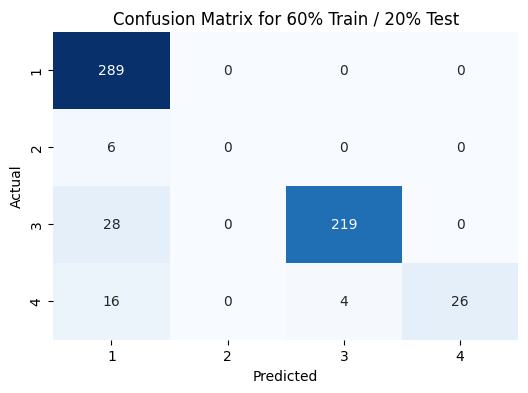

Results for 60% train / 20% test:
Accuracy: 0.9082
F1 Score: 0.9003
----------------------------------------


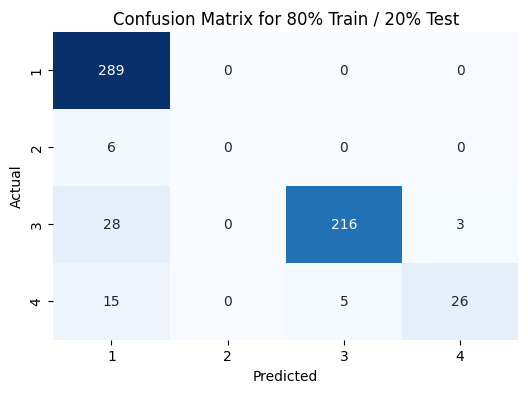

Results for 80% train / 20% test:
Accuracy: 0.9031
F1 Score: 0.8951
----------------------------------------
{'split': '20% train / 20% test', 'accuracy': 0.8197278911564626, 'f1_score': np.float64(0.8125945350024276), 'confusion_matrix': array([[249,   0,  40,   0],
       [  6,   0,   0,   0],
       [ 35,   0, 209,   3],
       [ 13,   0,   9,  24]])}
{'split': '40% train / 20% test', 'accuracy': 0.8860544217687075, 'f1_score': np.float64(0.877426464064893), 'confusion_matrix': array([[289,   0,   0,   0],
       [  6,   0,   0,   0],
       [ 39,   0, 207,   1],
       [ 13,   0,   8,  25]])}
{'split': '60% train / 20% test', 'accuracy': 0.9081632653061225, 'f1_score': np.float64(0.9003327326624133), 'confusion_matrix': array([[289,   0,   0,   0],
       [  6,   0,   0,   0],
       [ 28,   0, 219,   0],
       [ 16,   0,   4,  26]])}
{'split': '80% train / 20% test', 'accuracy': 0.9030612244897959, 'f1_score': np.float64(0.8950816435026961), 'confusion_matrix': array([[289,   0, 

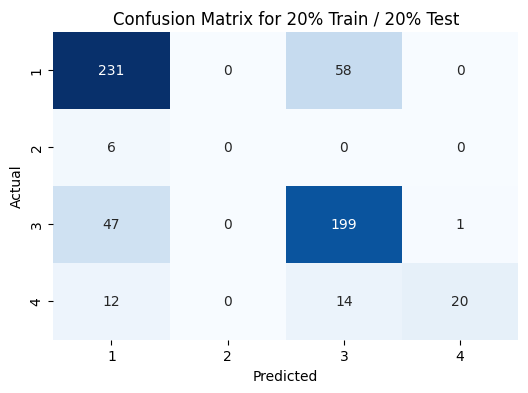

Results for 20% train / 20% test:
Accuracy: 0.7653
F1 Score: 0.7576
----------------------------------------


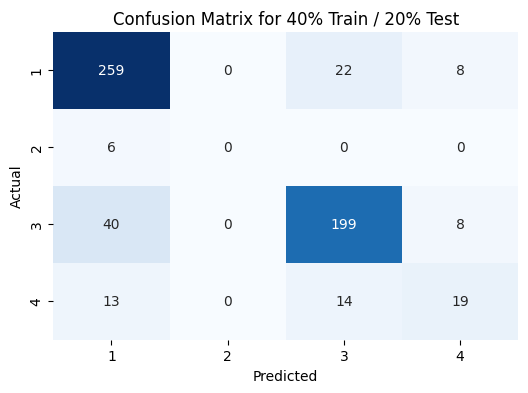

Results for 40% train / 20% test:
Accuracy: 0.8112
F1 Score: 0.8030
----------------------------------------


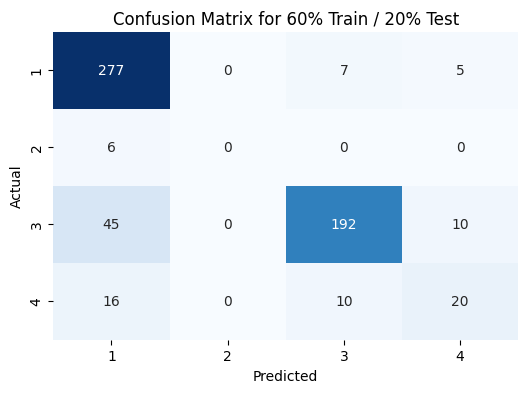

Results for 60% train / 20% test:
Accuracy: 0.8316
F1 Score: 0.8225
----------------------------------------


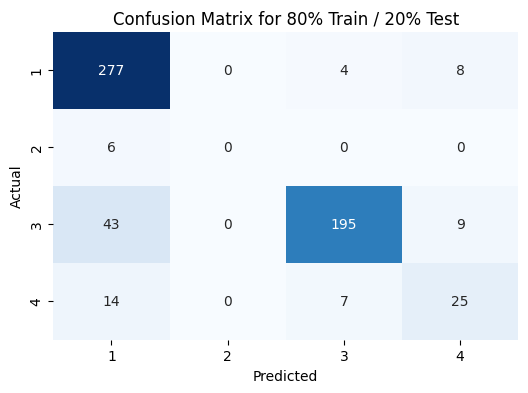

Results for 80% train / 20% test:
Accuracy: 0.8452
F1 Score: 0.8390
----------------------------------------


[{'split': '20% train / 20% test',
  'accuracy': 0.7653061224489796,
  'f1_score': np.float64(0.7576165081343271),
  'confusion_matrix': array([[231,   0,  58,   0],
         [  6,   0,   0,   0],
         [ 47,   0, 199,   1],
         [ 12,   0,  14,  20]])},
 {'split': '40% train / 20% test',
  'accuracy': 0.8112244897959183,
  'f1_score': np.float64(0.8029942745137576),
  'confusion_matrix': array([[259,   0,  22,   8],
         [  6,   0,   0,   0],
         [ 40,   0, 199,   8],
         [ 13,   0,  14,  19]])},
 {'split': '60% train / 20% test',
  'accuracy': 0.8316326530612245,
  'f1_score': np.float64(0.8225308144438513),
  'confusion_matrix': array([[277,   0,   7,   5],
         [  6,   0,   0,   0],
         [ 45,   0, 192,  10],
         [ 16,   0,  10,  20]])},
 {'split': '80% train / 20% test',
  'accuracy': 0.8452380952380952,
  'f1_score': np.float64(0.8389896442167019),
  'confusion_matrix': array([[277,   0,   4,   8],
         [  6,   0,   0,   0],
         [ 43,   

In [96]:
# Run progressive validation
print("XGBoost Results:")
progressive_results_xgb = progressive_validation(best_model_xgb, x_standardized, pd.Series(y_adjusted), groups)

# Print final results
for result in progressive_results_xgb:
    print(result)

# Run progressive validation
print("Random Forest Results:")
progressive_results_rf = progressive_validation(best_rf_model, x_standardized, y, groups)

# Print final results
for result in progressive_results_rf:
    print(result)

# KNN Model
tuned_knn_model = KNeighborsClassifier(**knn_best_params.get_params())
print("KNN Results:")
progressive_validation(tuned_knn_model, x_standardized, y, groups)

#### Run the model without Additional Skirt Info

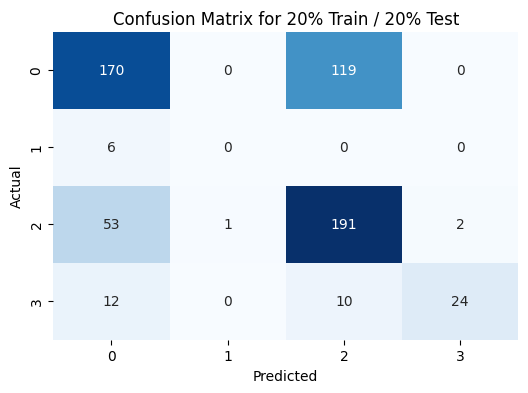

Results for 20% train / 20% test:
Accuracy: 0.6548
F1 Score: 0.6505
----------------------------------------


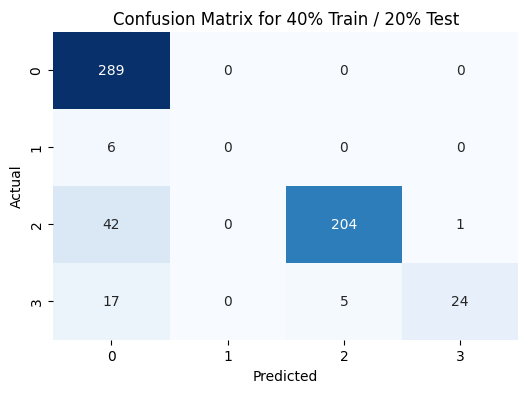

Results for 40% train / 20% test:
Accuracy: 0.8793
F1 Score: 0.8706
----------------------------------------


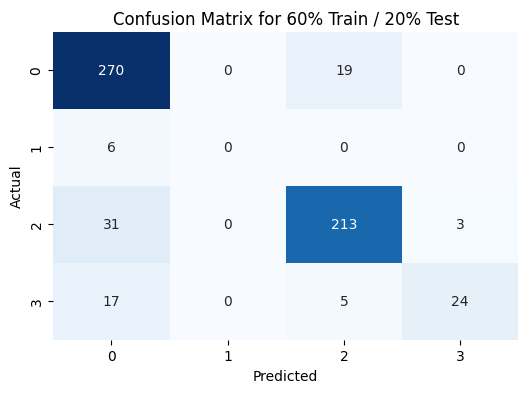

Results for 60% train / 20% test:
Accuracy: 0.8622
F1 Score: 0.8541
----------------------------------------


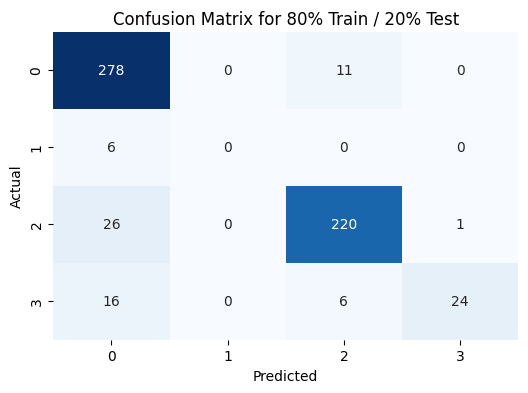

Results for 80% train / 20% test:
Accuracy: 0.8878
F1 Score: 0.8791
----------------------------------------
XGBoost Results:
{'split': '20% train / 20% test', 'accuracy': 0.6547619047619048, 'f1_score': np.float64(0.6504626941455761), 'confusion_matrix': array([[170,   0, 119,   0],
       [  6,   0,   0,   0],
       [ 53,   1, 191,   2],
       [ 12,   0,  10,  24]])}
{'split': '40% train / 20% test', 'accuracy': 0.8792517006802721, 'f1_score': np.float64(0.8705509737682556), 'confusion_matrix': array([[289,   0,   0,   0],
       [  6,   0,   0,   0],
       [ 42,   0, 204,   1],
       [ 17,   0,   5,  24]])}
{'split': '60% train / 20% test', 'accuracy': 0.8622448979591837, 'f1_score': np.float64(0.8541350592505402), 'confusion_matrix': array([[270,   0,  19,   0],
       [  6,   0,   0,   0],
       [ 31,   0, 213,   3],
       [ 17,   0,   5,  24]])}
{'split': '80% train / 20% test', 'accuracy': 0.8877551020408163, 'f1_score': np.float64(0.8791136783039417), 'confusion_matrix': 

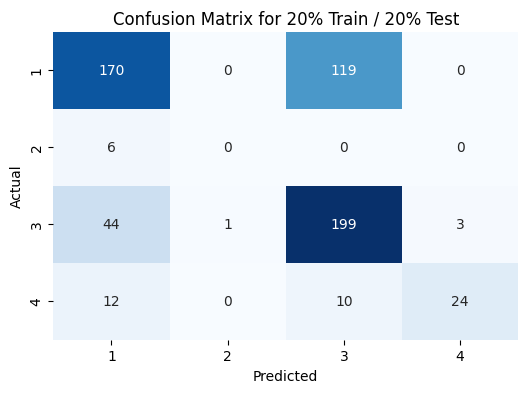

Results for 20% train / 20% test:
Accuracy: 0.6684
F1 Score: 0.6629
----------------------------------------


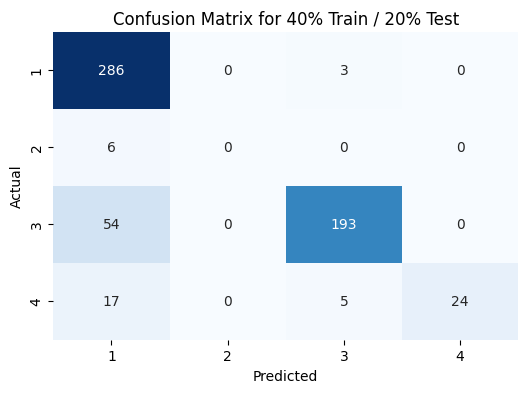

Results for 40% train / 20% test:
Accuracy: 0.8554
F1 Score: 0.8468
----------------------------------------


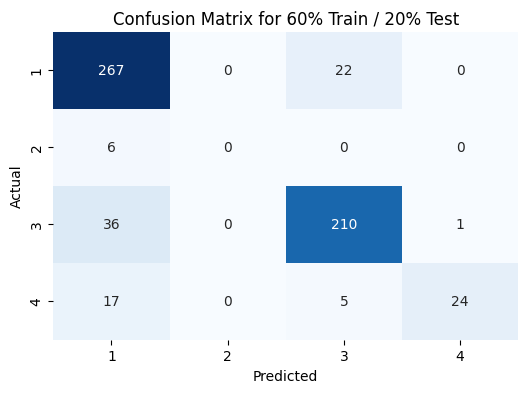

Results for 60% train / 20% test:
Accuracy: 0.8520
F1 Score: 0.8442
----------------------------------------


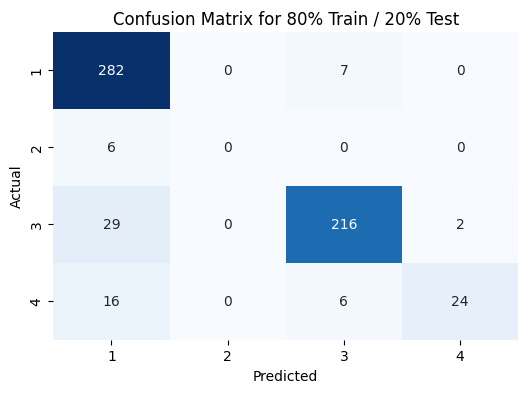

Results for 80% train / 20% test:
Accuracy: 0.8878
F1 Score: 0.8791
----------------------------------------
Random Forest Results:
{'split': '20% train / 20% test', 'accuracy': 0.6683673469387755, 'f1_score': np.float64(0.6629462248855901), 'confusion_matrix': array([[170,   0, 119,   0],
       [  6,   0,   0,   0],
       [ 44,   1, 199,   3],
       [ 12,   0,  10,  24]])}
{'split': '40% train / 20% test', 'accuracy': 0.8554421768707483, 'f1_score': np.float64(0.8467681951176615), 'confusion_matrix': array([[286,   0,   3,   0],
       [  6,   0,   0,   0],
       [ 54,   0, 193,   0],
       [ 17,   0,   5,  24]])}
{'split': '60% train / 20% test', 'accuracy': 0.8520408163265306, 'f1_score': np.float64(0.8441735032148913), 'confusion_matrix': array([[267,   0,  22,   0],
       [  6,   0,   0,   0],
       [ 36,   0, 210,   1],
       [ 17,   0,   5,  24]])}
{'split': '80% train / 20% test', 'accuracy': 0.8877551020408163, 'f1_score': np.float64(0.8790581306783929), 'confusion_mat

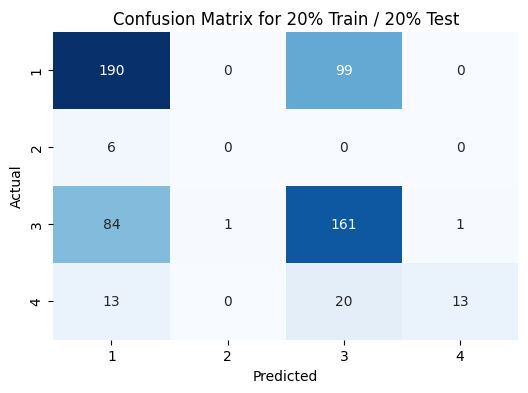

Results for 20% train / 20% test:
Accuracy: 0.6190
F1 Score: 0.6115
----------------------------------------


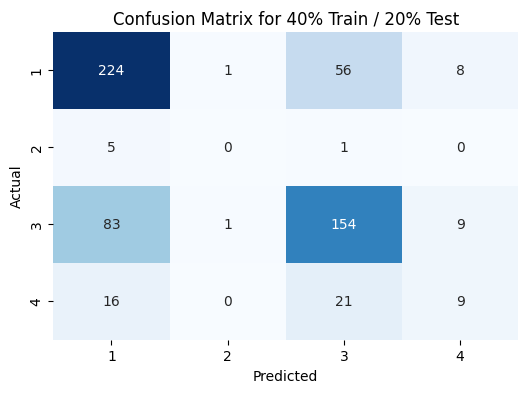

Results for 40% train / 20% test:
Accuracy: 0.6582
F1 Score: 0.6465
----------------------------------------


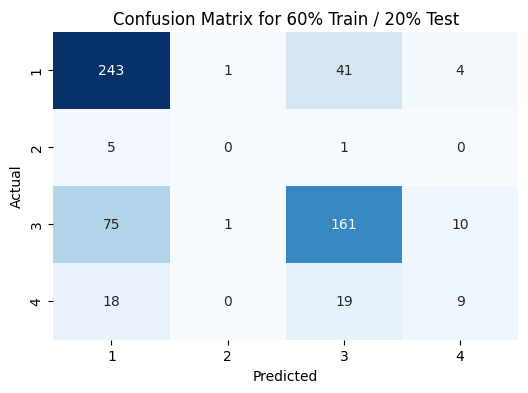

Results for 60% train / 20% test:
Accuracy: 0.7024
F1 Score: 0.6880
----------------------------------------


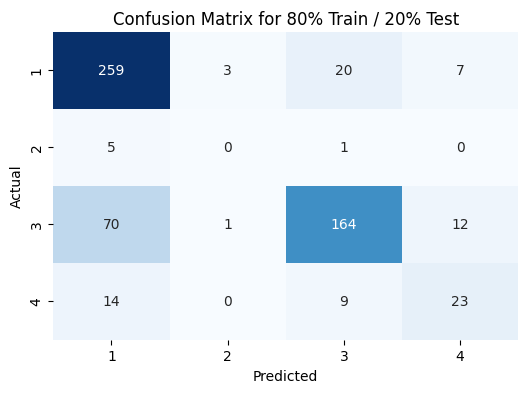

Results for 80% train / 20% test:
Accuracy: 0.7585
F1 Score: 0.7530
----------------------------------------


[{'split': '20% train / 20% test',
  'accuracy': 0.6190476190476191,
  'f1_score': np.float64(0.6114726147636751),
  'confusion_matrix': array([[190,   0,  99,   0],
         [  6,   0,   0,   0],
         [ 84,   1, 161,   1],
         [ 13,   0,  20,  13]])},
 {'split': '40% train / 20% test',
  'accuracy': 0.6581632653061225,
  'f1_score': np.float64(0.6465369284177739),
  'confusion_matrix': array([[224,   1,  56,   8],
         [  5,   0,   1,   0],
         [ 83,   1, 154,   9],
         [ 16,   0,  21,   9]])},
 {'split': '60% train / 20% test',
  'accuracy': 0.7023809523809523,
  'f1_score': np.float64(0.6879675964202313),
  'confusion_matrix': array([[243,   1,  41,   4],
         [  5,   0,   1,   0],
         [ 75,   1, 161,  10],
         [ 18,   0,  19,   9]])},
 {'split': '80% train / 20% test',
  'accuracy': 0.7585034013605442,
  'f1_score': np.float64(0.7530037315022738),
  'confusion_matrix': array([[259,   3,  20,   7],
         [  5,   0,   1,   0],
         [ 70,   

In [97]:
x_standardized = x_standardized.drop(['Feature20'],axis=1)   #additional_skirt_information

progressive_results_xgb = progressive_validation(best_model_xgb, x_standardized, pd.Series(y_adjusted), groups)
print("XGBoost Results:")
# Print final results
for result in progressive_results_xgb:
    print(result)

# Run progressive validation
progressive_results_rf = progressive_validation(best_rf_model, x_standardized, y, groups)
print("Random Forest Results:")
# Print final results
for result in progressive_results_rf:
    print(result)

# KNN Model
tuned_knn_model = KNeighborsClassifier(**knn_best_params.get_params())
print("KNN Results:")
progressive_validation(tuned_knn_model, x_standardized, y, groups)